In [1]:
#Imports
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# Constants
MICRONS_PER_PIXEL = 22.5  # µm/pixel
DEPTH_MM = 500  # mm, sampled depth (all in focus)

def extract_pressure_from_filename(filename):
    """Extract pressure value in bar from filename."""
    match = re.search(r'(\d+\.\d+)bar', filename)
    if match:
        return float(match.group(1))
    return None

def get_mask_radius(profile_path):
    """Read mask_radius from settings.csv in the profile folder."""
    settings_file = Path(profile_path) / 'settings.csv'
    
    if not settings_file.exists():
        print(f"    settings.csv not found at {settings_file}")
        return None
    
    try:
        df = pd.read_csv(settings_file)
        # Settings file has 'Field Name' and 'Value' columns
        mask_row = df[df['Field Name'] == 'mask_radius']
        if not mask_row.empty:
            return float(mask_row['Value'].iloc[0])
        else:
            print(f"    mask_radius field not found in settings.csv")
            return None
    except Exception as e:
        print(f"    Error reading settings.csv: {e}")
        return None

def calculate_volume(mask_radius_pixels):
    """Calculate sampled volume in liters.
    
    Volume = π * r² * depth
    where r is in mm and depth is in mm
    """
    # Convert radius from pixels to mm
    radius_microns = mask_radius_pixels * MICRONS_PER_PIXEL
    radius_mm = radius_microns / 1000  # µm to mm
    
    # Calculate volume in mm³
    volume_mm3 = np.pi * (radius_mm ** 2) * DEPTH_MM
    
    # Convert to liters (1 L = 1,000,000 mm³)
    volume_liters = volume_mm3 / 1_000_000
    
    return volume_liters

In [2]:
def process_single_profile_tsv_with_custom_bins(tsv_file_path, image_folder_path, profile_name, mask_radius, 
                                                 depth_bin_edges=[0, 100, 500, 1000, 2000, 4000, 10000]):
    """Process a single profile TSV file and calculate concentrations per CUSTOM depth bins.
    
    Args:
        tsv_file_path: Path to the TSV file (EcoTaxa format)
        image_folder_path: Path to folder containing PNG images for this profile
        profile_name: Name/identifier for the profile
        mask_radius: Mask radius in pixels (for volume calculation)
        depth_bin_edges: List of depth bin edges in dbar (e.g., [0, 100, 500, 1000, 2000, 4000, 10000])
    
    Returns:
        result_df: DataFrame with profile, depth bins, categories, counts, volumes and concentrations
        volume_df: DataFrame with just depth bins and sampled volumes (for later use)
    """
    print(f"Processing {profile_name}...")
    
    # Calculate volume per image
    volume_per_image = calculate_volume(mask_radius)
    print(f"  Mask radius: {mask_radius} pixels, Volume per image: {volume_per_image:.6f} L")
    
    # Calculate exact volumes per depth bin from actual images
    png_folder = Path(image_folder_path) / 'PNG'
    if not png_folder.exists():
        print(f"  Error: PNG folder not found at {png_folder}")
        return pd.DataFrame(), pd.DataFrame()
    
    image_files = list(png_folder.glob('*.png'))
    print(f"  Found {len(image_files)} images")
    
    # ============ STEP 1: Calculate volumes per custom depth bin ============
    # Create depth bin labels
    depth_bin_labels = [f'{depth_bin_edges[i]}-{depth_bin_edges[i+1]}m' 
                        for i in range(len(depth_bin_edges)-1)]
    
    # Track volumes per depth bin
    volumes_by_depth_bin = defaultdict(float)
    
    for image_file in image_files:
        pressure_bar = extract_pressure_from_filename(image_file.name)
        if pressure_bar is not None:
            # Convert pressure in bar to dbar (1 bar = 10 dbar)
            pressure_dbar = pressure_bar * 10
            
            # Assign to custom depth bin using pd.cut
            # Use right=False to make intervals [a, b) instead of (a, b]
            bin_idx = pd.cut([pressure_dbar], bins=depth_bin_edges, labels=False, 
                            include_lowest=True, right=False)[0]
            
            if not pd.isna(bin_idx):
                depth_label = depth_bin_labels[int(bin_idx)]
                volumes_by_depth_bin[depth_label] += volume_per_image
    
    print(f"  Calculated volumes for {len(volumes_by_depth_bin)} custom depth bins")
    print(f"  Depth bins: {list(volumes_by_depth_bin.keys())}")
    
    # Create volume DataFrame
    volume_records = []
    for depth_label, volume in volumes_by_depth_bin.items():
        # Extract start and end from label (e.g., "0-100m" -> 0, 100)
        start, end = depth_label.replace('m', '').split('-')
        volume_records.append({
            'profile': profile_name,
            'depth_bin_start_dbar': float(start),
            'depth_bin_end_dbar': float(end),
            'depth_bin_label': depth_label,
            'sampled_volume_L': volume
        })
    
    volume_df = pd.DataFrame(volume_records).sort_values('depth_bin_start_dbar')
    
    
    # ============ STEP 2: Process TSV file for counts ============
    try:
        # Read TSV file, skipping the second row (datatype indicator)
        df = pd.read_csv(tsv_file_path, sep='\t', skiprows=[1])
        
        # Check for required columns
        if 'object_pressure' not in df.columns or 'object_annotation_category' not in df.columns:
            print(f"  Error: Required columns not found in TSV")
            return pd.DataFrame(), volume_df
        
        # Convert pressure to dbar
        df['pressure_dbar'] = df['object_pressure']
        
        # Calculate individual biovolume from ESD
        if 'object_esd' in df.columns:
            esd_mm = df['object_esd'] / 1000  # µm to mm
            df['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
        else:
            print(f"  Warning: object_esd column not found, biovolume will not be calculated")
            df['biovolume_mm3'] = 0
        
        # Assign to custom depth bins
        df['depth_bin'] = pd.cut(df['pressure_dbar'], 
                                  bins=depth_bin_edges, 
                                  labels=depth_bin_labels,
                                  include_lowest=True,
                                  right=False)
        
        # Count occurrences and sum biovolume per depth bin and category
        counts = df.groupby(['depth_bin', 'object_annotation_category'], observed=True).agg({
            'biovolume_mm3': 'sum',  # Total biovolume in mm³
            'object_annotation_category': 'size',  # Count of objects
        }).rename(columns={'object_annotation_category': 'count'}).reset_index()
        
        # ✅ FIX: Convert depth_bin to string before mapping, then convert volume to float
        counts['depth_bin'] = counts['depth_bin'].astype(str)
        counts['sampled_volume_L'] = counts['depth_bin'].map(volumes_by_depth_bin).astype(float)
        
        # Extract start and end from depth_bin label
        counts[['depth_bin_start_dbar', 'depth_bin_end_dbar']] = counts['depth_bin'].str.replace('m', '').str.split('-', expand=True).astype(float)
        
        # Add profile information
        counts['profile'] = profile_name
        
        # Calculate concentration (organisms per liter)
        counts['concentration_per_L'] = counts['count'] / counts['sampled_volume_L']
        
        # Calculate biovolume per liter (mm³/L)
        counts['biovolume_mm3_per_L'] = counts['biovolume_mm3'] / counts['sampled_volume_L']
        
        # Reorder columns
        counts = counts[['profile', 'depth_bin_start_dbar', 'depth_bin_end_dbar', 'depth_bin',
                        'object_annotation_category', 'count', 'biovolume_mm3',
                        'sampled_volume_L', 'concentration_per_L', 'biovolume_mm3_per_L']]
        
        print(f"  Found {len(df)} objects in {len(counts['object_annotation_category'].unique())} categories")
        print(f"  Depth range: {df['pressure_dbar'].min():.1f} - {df['pressure_dbar'].max():.1f} dbar")
        print(f"  Total organisms: {counts['count'].sum()}")
        print(f"  Total sampled volume: {volume_df['sampled_volume_L'].sum():.2f} L") 
        print(f"  Total biovolume: {counts['biovolume_mm3'].sum():.2f} mm³")
        
        return counts, volume_df
        
    except Exception as e:
        print(f"  Error processing TSV: {e}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame(), volume_df


In [10]:
# ============ MULTIPLE PROFILES CONFIGURATION ============

# PIScO profiles (list of dictionaries)
pisco_profiles = [
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-175-1_CTD-050_00Â°00S-019Â°00W_20220509-0543.tsv",
        'profile_name': "M181-175-1_CTD-050_00°00S-019°00W_20220509-0543",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/PISCO_CTD037_data.tsv",
        'profile_name': "M181-112-1_CTD-037_00°00S-008°00W_20220504-1758",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-227-1_CTD-060_00Â°00S-027Â°00W_20220512-1748.tsv",
        'profile_name': "M181-227-1_CTD-060_00°00S-027°00W_20220512-1748",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-285-1_CTD-075_00Â°00S-039Â°00W_20220517-2024.tsv",
        'profile_name': "M181-285-1_CTD-075_00°00S-039°00W_20220517-2024",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-297-1_CTD-081_00Â°00S-041Â°50W_20220519-0218.tsv",
        'profile_name': "M181-297-1_CTD-081_00°00S-041°50W_20220519-0218",
        'mask_radius': 1550
    },
]

# PIScO image folder base path
pisco_image_base = "/mnt/filer/M181/M181-PISCO-Profiles"

# UVP5 samples (list of dictionaries with sample_id and volume_path)
uvp5_samples = [
    {
        'sample_id': "c_m181_050",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_050.tsv"
    },
    {
        'sample_id': "c_m181_037",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"
    },
    {
        'sample_id': "c_m181_060",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_060.tsv"
    },
    {
        'sample_id': "c_m181_075",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_075.tsv"
    },
    {
        'sample_id': "c_m181_081",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_081.tsv"
    },
]

# UVP5 data paths
tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
uvp5_volume_path = "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"

# Define depth bins
depth_bin_edges = [0, 200, 1000, 10000]
depth_bin_labels = [f'{depth_bin_edges[i]}-{depth_bin_edges[i+1]}m' 
                    for i in range(len(depth_bin_edges)-2)]
depth_bin_labels.append('1000+m')

print(f"Depth bin labels: {depth_bin_labels}")

# ============ BIN BY ESD ============
esd_bin_edges = np.logspace(np.log10(50), np.log10(10000), 30)

Depth bin labels: ['0-200m', '200-1000m', '1000+m']


In [12]:
# ============ PROCESS ALL PIScO PROFILES ============
print("\n" + "="*80)
print("PROCESSING PIScO PROFILES")
print("="*80)

all_copepod_pisco = []
all_pisco_volumes = defaultdict(float)  # Accumulate volumes per depth bin

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    mask_radius = profile_config['mask_radius']
    image_folder_path = os.path.join(pisco_image_base, profile_name)
    
    print(f"\nProcessing PIScO profile: {profile_name}")
    
    # Process this profile
    result_df, volume_df = process_single_profile_tsv_with_custom_bins(
        tsv_path, image_folder_path, profile_name, mask_radius, 
        depth_bin_edges=depth_bin_edges
    )
    
    # Read copepod data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    df_pisco.loc[df_pisco['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'
    df_pisco.loc[df_pisco['object_annotation_category'] == 'Oitona', 'object_annotation_category'] = 'Copepoda<Maxillopoda'
    copepod_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()
    
    # Calculate biovolume
    copepod_pisco['esd_um'] = copepod_pisco['object_esd']
    esd_mm = copepod_pisco['esd_um'] / 1000
    copepod_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    copepod_pisco['depth_bin'] = pd.cut(copepod_pisco['pressure_dbar'], 
                                         bins=depth_bin_edges, 
                                         labels=depth_bin_labels,
                                         include_lowest=True,
                                         right=False)
    
    copepod_pisco['profile'] = profile_name
    all_copepod_pisco.append(copepod_pisco)
    
    # Accumulate volumes
    volume_df_mapped = volume_df.copy()
    volume_df_mapped['depth_bin_label'] = volume_df_mapped['depth_bin_label'].replace('1000-10000m', '1000+m')
    for _, row in volume_df_mapped.iterrows():
        all_pisco_volumes[row['depth_bin_label']] += row['sampled_volume_L']

# Combine all PIScO data
copepod_pisco = pd.concat(all_copepod_pisco, ignore_index=True)
pisco_depth_volumes = dict(all_pisco_volumes)

print(f"\n✅ Combined PIScO data: {len(copepod_pisco)} copepods from {len(pisco_profiles)} profiles")
print("\nCombined PIScO volumes by depth:")
for label, vol in pisco_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


PROCESSING PIScO PROFILES

Processing PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
Processing M181-175-1_CTD-050_00°00S-019°00W_20220509-0543...
  Mask radius: 1550 pixels, Volume per image: 1.910506 L
  Found 20521 images
  Calculated volumes for 3 custom depth bins
  Depth bins: ['200-1000m', '0-200m', '1000-10000m']
  Found 11990 objects in 14 categories
  Depth range: 10.0 - 4445.5 dbar
  Total organisms: 11990
  Total sampled volume: 39205.48 L
  Total biovolume: 58041.19 mm³

Processing PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
Processing M181-112-1_CTD-037_00°00S-008°00W_20220504-1758...
  Mask radius: 1550 pixels, Volume per image: 1.910506 L
  Found 24347 images
  Calculated volumes for 3 custom depth bins
  Depth bins: ['1000-10000m', '200-1000m', '0-200m']
  Found 3550 objects in 6 categories
  Depth range: 10.3 - 5277.5 dbar
  Total organisms: 3550
  Total sampled volume: 46515.08 L
  Total biovolume: 13060.52 mm³

Processing PIScO pr

In [14]:
# ============ PROCESS ALL UVP5 SAMPLES ============
print("\n" + "="*80)
print("PROCESSING UVP5 SAMPLES")
print("="*80)

# Read UVP5 copepod data (all samples)
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])

# Extract sample IDs from config
sample_ids = [s['sample_id'] for s in uvp5_samples]

# Filter for selected samples only
df_uvp5 = df_uvp5[df_uvp5['sample_id'].isin(sample_ids)].copy()

print(f"Processing UVP5 samples: {sample_ids}")

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for validated copepods only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated annotations only...")
    copepod_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
else:
    copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

print(f"✅ Combined UVP5 data: {len(copepod_uvp5)} validated copepods from {len(uvp5_samples)} samples")

# Calculate biovolume
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88
esd_mm_uvp5 = copepod_uvp5['esd_um'] / 1000
copepod_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
copepod_uvp5['pressure_dbar'] = copepod_uvp5['object_depth_min']

# Assign depth bins
copepod_uvp5['depth_bin'] = pd.cut(copepod_uvp5['pressure_dbar'], 
                                    bins=depth_bin_edges, 
                                    labels=depth_bin_labels,
                                    include_lowest=True,
                                    right=False)

# ============ LOAD AND COMBINE VOLUME DATA FROM EACH SAMPLE ============
all_uvp5_volume_dfs = []

for sample_config in uvp5_samples:
    sample_id = sample_config['sample_id']
    volume_path = sample_config['volume_path']
    
    print(f"\nLoading volume data for {sample_id} from {volume_path}")
    
    try:
        df_volume = pd.read_csv(volume_path, sep='\t', encoding='latin-1')
        df_volume['sample_id'] = sample_id  # Tag with sample ID
        all_uvp5_volume_dfs.append(df_volume)
        print(f"  ✅ Loaded {len(df_volume)} depth bins")
    except Exception as e:
        print(f"  ❌ Error loading {volume_path}: {e}")

# Combine all volume data
df_uvp5_volume_combined = pd.concat(all_uvp5_volume_dfs, ignore_index=True)

print(f"\n✅ Combined volume data: {len(df_uvp5_volume_combined)} rows from {len(uvp5_samples)} samples")

# Calculate UVP5 volumes per depth bin (summed across all samples)
df_uvp5_volume_combined['depth_bin'] = pd.cut(df_uvp5_volume_combined['Depth [m]'], 
                                               bins=depth_bin_edges, 
                                               labels=depth_bin_labels,
                                               include_lowest=True,
                                               right=False)
uvp5_depth_volumes = df_uvp5_volume_combined.groupby('depth_bin', observed=True)['Sampled volume [L]'].sum().to_dict()

print("\nCombined UVP5 volumes by depth:")
for label, vol in uvp5_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")



PROCESSING UVP5 SAMPLES
Processing UVP5 samples: ['c_m181_050', 'c_m181_037', 'c_m181_060', 'c_m181_075', 'c_m181_081']
✅ Filtering for validated annotations only...
✅ Combined UVP5 data: 585 validated copepods from 5 samples

Loading volume data for c_m181_050 from /home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_050.tsv
  ✅ Loaded 888 depth bins

Loading volume data for c_m181_037 from /home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv
  ✅ Loaded 1054 depth bins

Loading volume data for c_m181_060 from /home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_060.tsv
  ✅ Loaded 668 depth bins

Loading volume data for c_m181_075 from /home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_075.tsv
  ✅ Loaded 871 depth bins

Loading volume data for c_m181_081 from /home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_081.tsv
  ✅


PROCESSING CLASS: COPEPODA
✅ Found 1736 Copepoda (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
✅ Found 1373 Copepoda (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects
✅ Found 822 Copepoda (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 1172 Copepoda (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 1937 Copepoda (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Copepoda data: 7040 objects from 5 profiles
✅ Found 1525 Copepoda (UVP5) objects
✅ After validation filter: 585 validated Copepoda objects


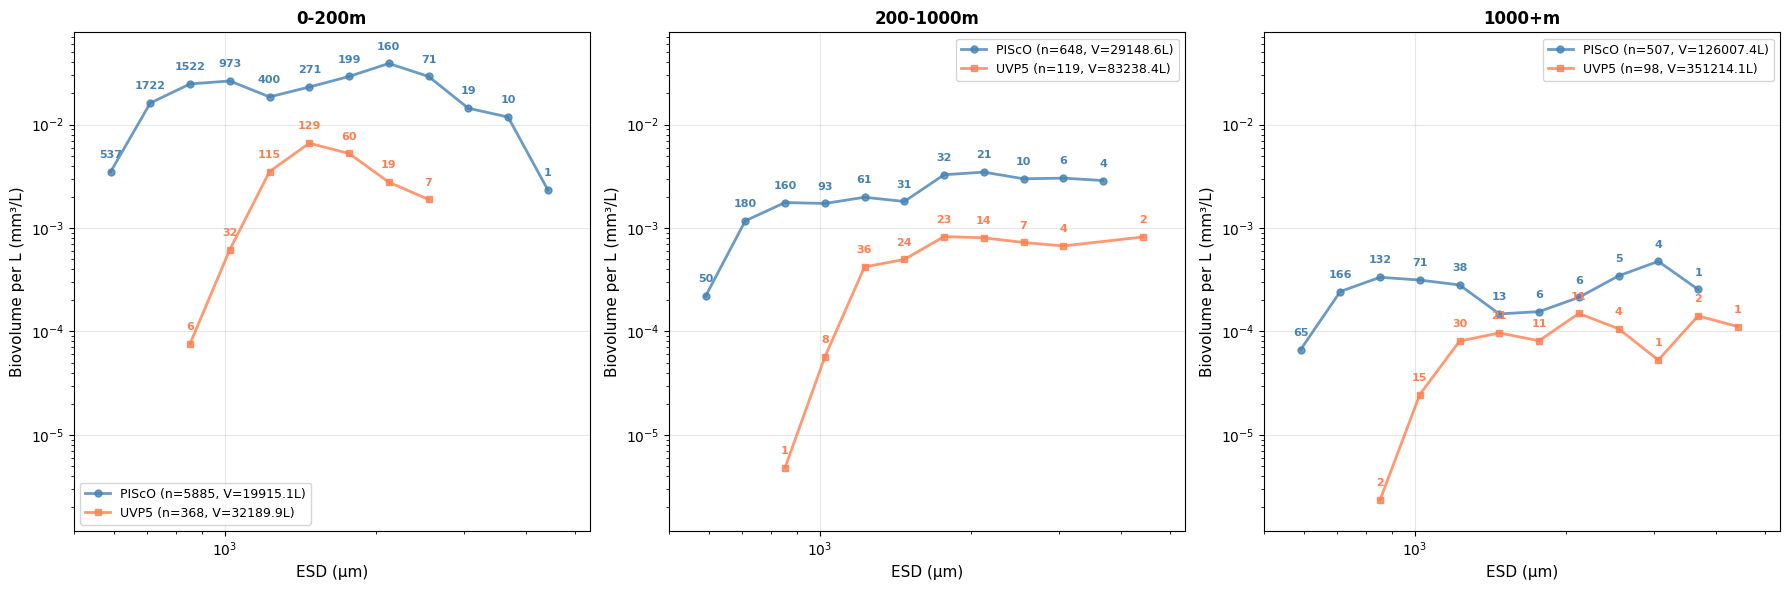


✅ Completed analysis for Copepoda

PROCESSING CLASS: RHIZARIA
✅ Found 162 Rhizaria (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
✅ Found 220 Rhizaria (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects
✅ Found 60 Rhizaria (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 303 Rhizaria (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 384 Rhizaria (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Rhizaria data: 1129 objects from 5 profiles
✅ Found 793 Rhizaria (UVP5) objects
✅ After validation filter: 720 validated Rhizaria objects


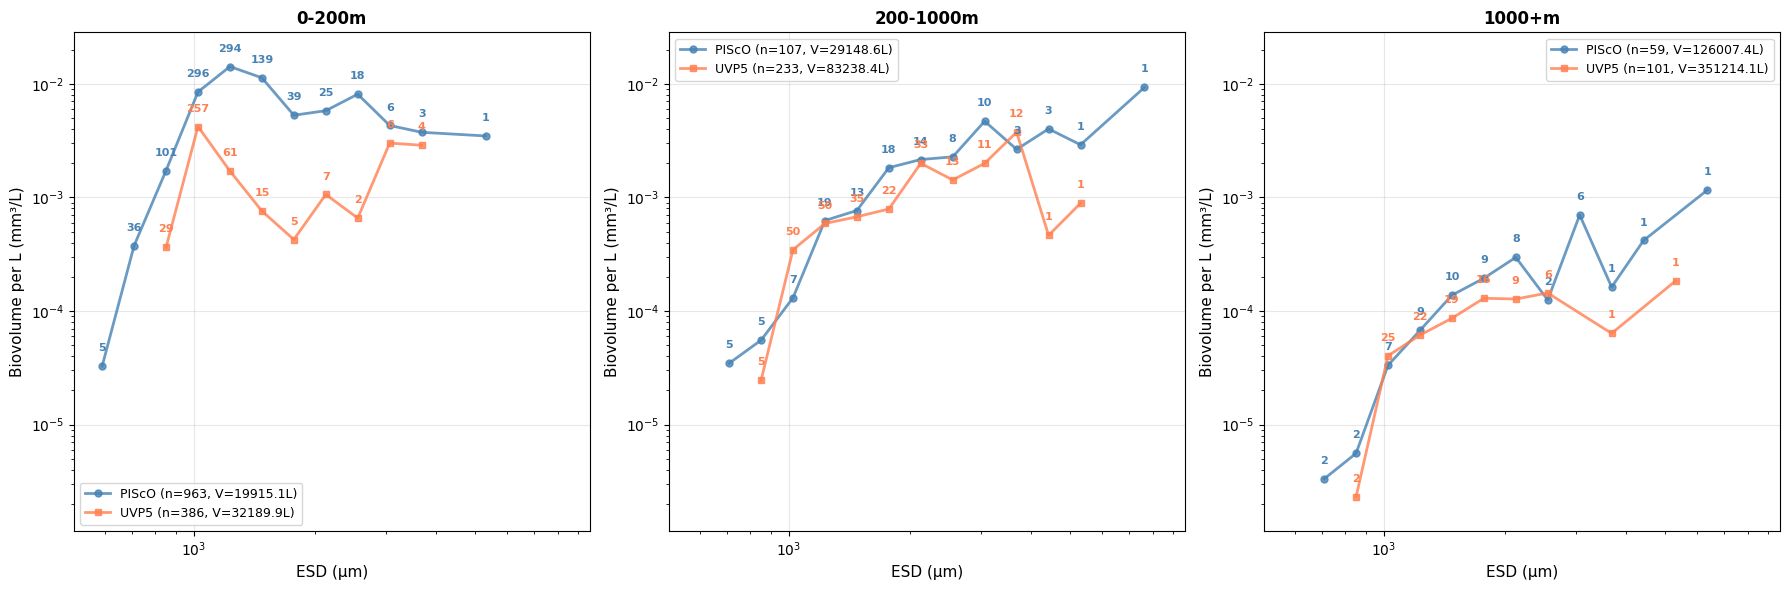


✅ Completed analysis for Rhizaria

PROCESSING CLASS: TRICHODESMIUM
✅ Found 9559 Trichodesmium (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
✅ Found 462 Trichodesmium (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects
✅ Found 4841 Trichodesmium (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 910 Trichodesmium (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 4154 Trichodesmium (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Trichodesmium data: 19926 objects from 5 profiles
✅ Found 2866 Trichodesmium (UVP5) objects
✅ After validation filter: 2796 validated Trichodesmium objects


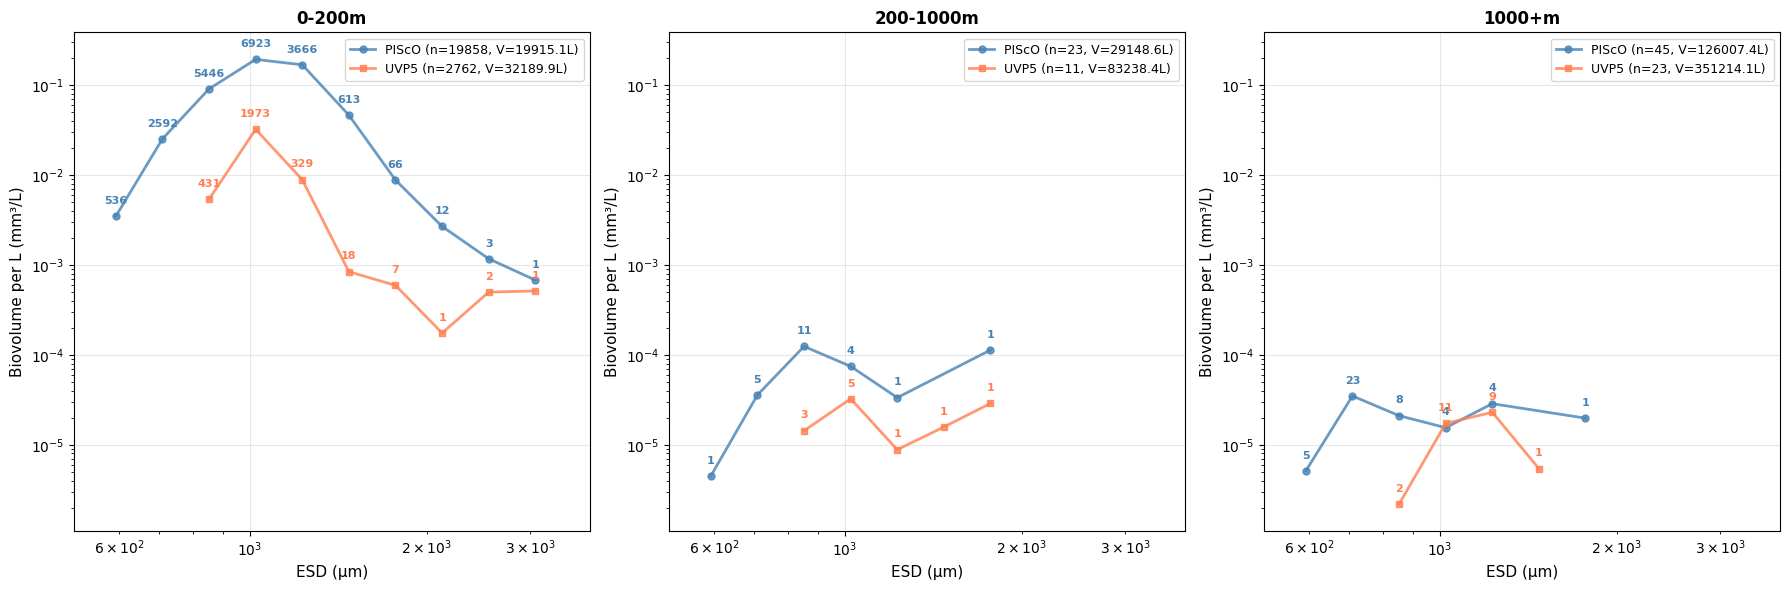


✅ Completed analysis for Trichodesmium

PROCESSING CLASS: CNIDARIA
✅ Found 135 Cnidaria (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
✅ Found 100 Cnidaria (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects
✅ Found 63 Cnidaria (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 47 Cnidaria (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 125 Cnidaria (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Cnidaria data: 470 objects from 5 profiles
✅ Found 13 Cnidaria (UVP5) objects
✅ After validation filter: 9 validated Cnidaria objects


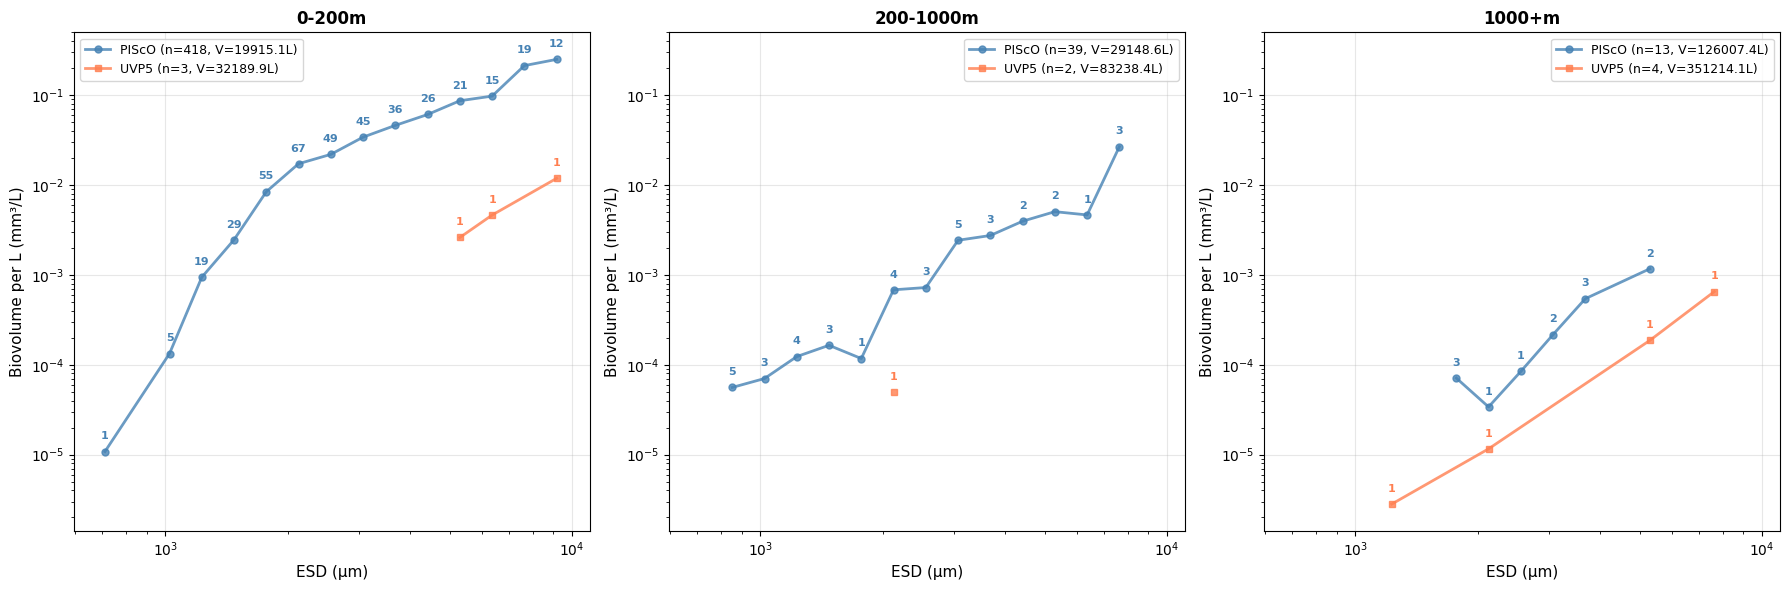


✅ Completed analysis for Cnidaria

PROCESSING CLASS: THALIACEA
✅ Found 45 Thaliacea (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
✅ Found 21 Thaliacea (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects
✅ Found 8 Thaliacea (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 10 Thaliacea (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 6 Thaliacea (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Thaliacea data: 90 objects from 5 profiles
❌ No Thaliacea (UVP5) objects found


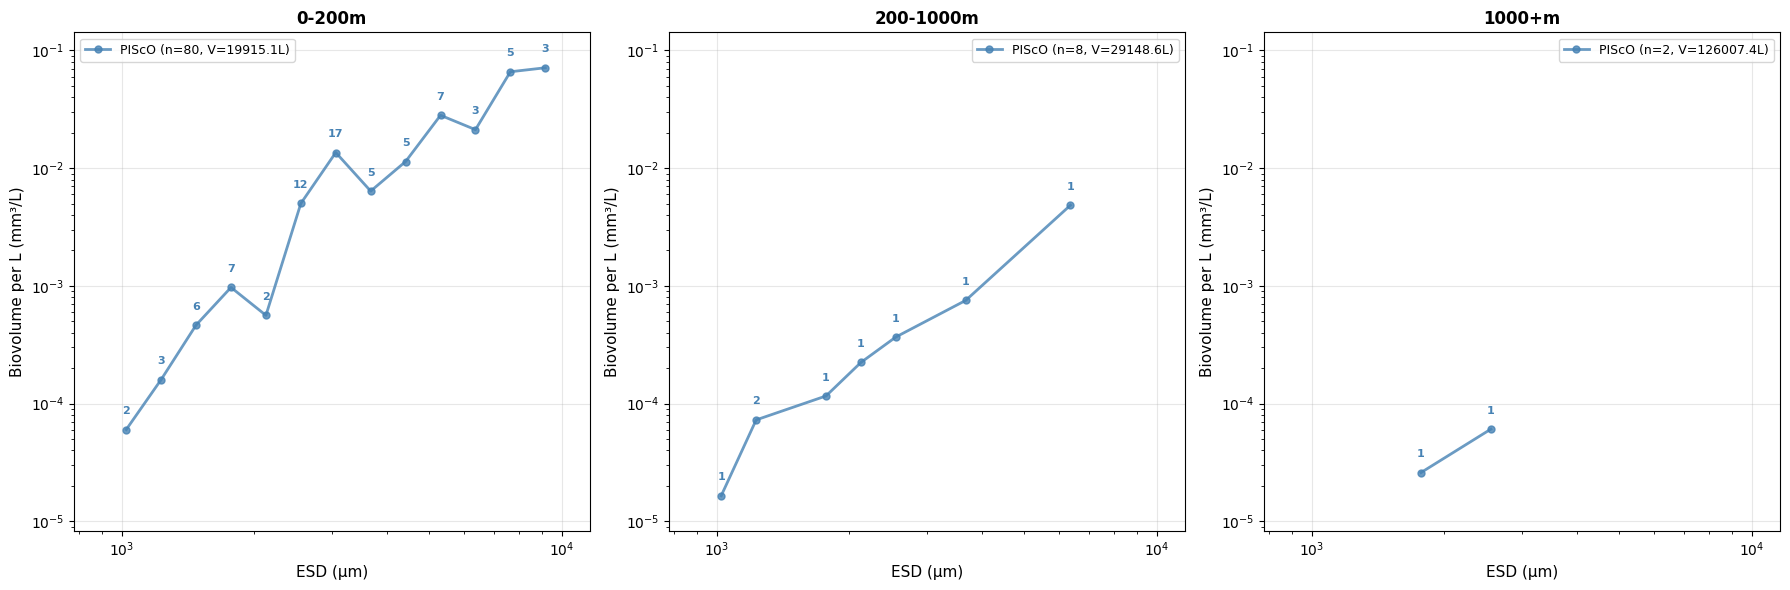


✅ Completed analysis for Thaliacea

PROCESSING CLASS: APPENDICULARIA
✅ Found 183 Appendicularia (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
✅ Found 1375 Appendicularia (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects
✅ Found 160 Appendicularia (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 845 Appendicularia (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 996 Appendicularia (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Appendicularia data: 3559 objects from 5 profiles
✅ Found 4 Appendicularia (UVP5) objects
✅ After validation filter: 2 validated Appendicularia objects


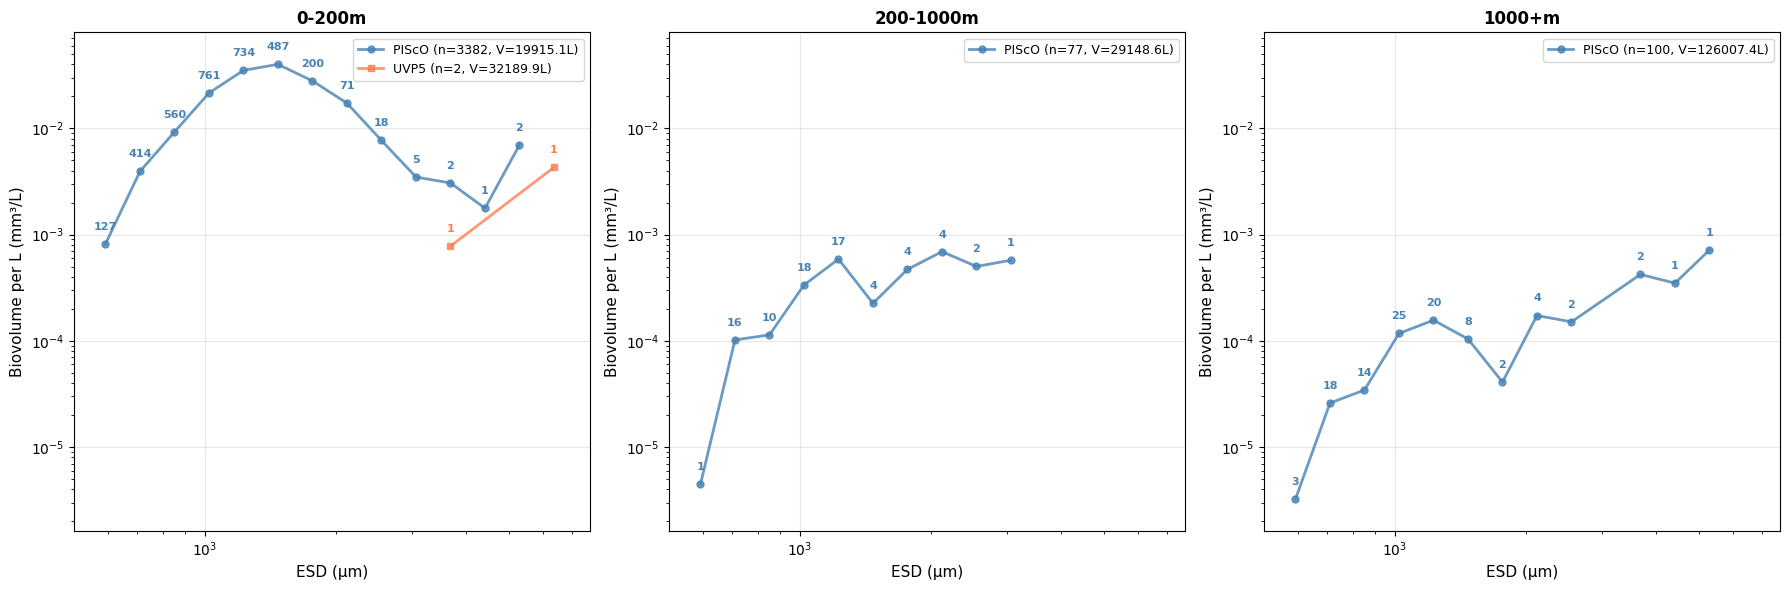


✅ Completed analysis for Appendicularia

PROCESSING CLASS: CHAETOGNATHA
✅ Found 13 Chaetognatha (PIScO M181-175-1_CTD-050_00°00S-019°00W_20220509-0543) objects
❌ No Chaetognatha (PIScO M181-112-1_CTD-037_00°00S-008°00W_20220504-1758) objects found
✅ Found 17 Chaetognatha (PIScO M181-227-1_CTD-060_00°00S-027°00W_20220512-1748) objects
✅ Found 14 Chaetognatha (PIScO M181-285-1_CTD-075_00°00S-039°00W_20220517-2024) objects
✅ Found 32 Chaetognatha (PIScO M181-297-1_CTD-081_00°00S-041°50W_20220519-0218) objects

✅ Combined PIScO Chaetognatha data: 76 objects from 4 profiles
✅ Found 34 Chaetognatha (UVP5) objects
✅ After validation filter: 24 validated Chaetognatha objects


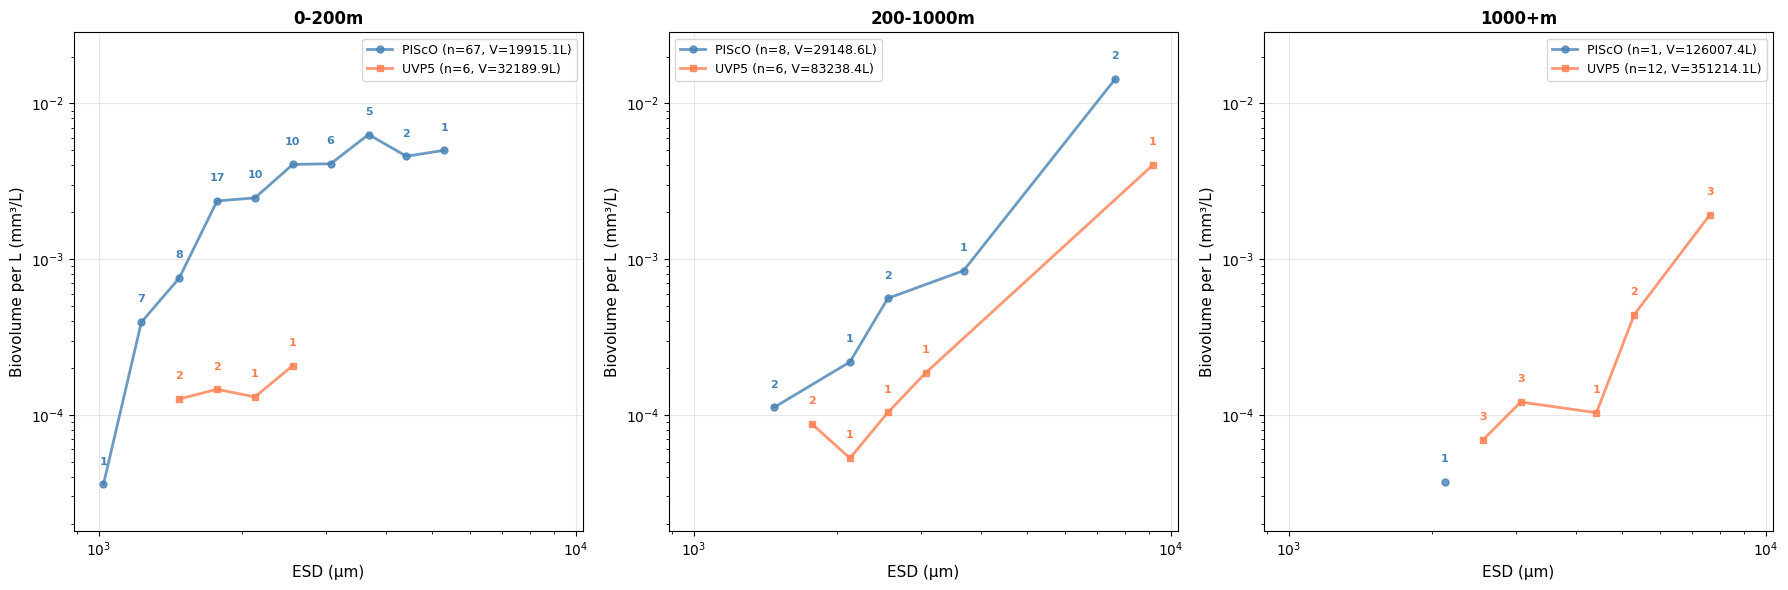


✅ Completed analysis for Chaetognatha


In [15]:
# ============ PROCESS MULTIPLE CLASSES ============

# Define the classes to analyze
classes_to_analyze = {
    'Copepoda': {
        'search_terms': ['Copepoda', 'Calanoida', 'Oitona'],
        'color': 'darkorange'
    },
    'Rhizaria': {
        'search_terms': ['Rhizaria'],
        'color': 'darkorange'
    },
    'Trichodesmium': {
        'search_terms': ['trichodesmium', 'puff', 'tuft'],
        'color': 'green'
    },
    'Cnidaria': {
        'search_terms': ['Cnidaria', 'hydromedusae', 'siphonophore'],
        'color': 'purple'
    },
    'Thaliacea': {
        'search_terms': ['Thaliacea', 'tunicate_salp', 'tunicate_doliolid'],
        'color': 'brown'
    },
    'Appendicularia': {
        'search_terms': ['Appendicularia', 'appendicularian'],
        'color': 'pink'
    },
    'Chaetognatha': {
        'search_terms': ['Chaetognatha', 'chaetognath'],
        'color': 'red'
    },
}

# Function to filter data for a specific class
def filter_class_data(df, class_info, class_name):
    """Filter dataframe for a specific taxonomic class"""
    search_terms = class_info['search_terms']
    
    # Create a boolean mask for all search terms
    mask = df['object_annotation_category'].str.contains('|'.join(search_terms), case=False, na=False)
    
    filtered_df = df[mask].copy()
    
    if len(filtered_df) > 0:
        print(f"✅ Found {len(filtered_df)} {class_name} objects")
    else:
        print(f"❌ No {class_name} objects found")
    
    return filtered_df

# Process each class
for class_name, class_info in classes_to_analyze.items():
    print(f"\n" + "="*80)
    print(f"PROCESSING CLASS: {class_name.upper()}")
    print("="*80)
    
    # ============ PROCESS PIScO DATA FOR THIS CLASS ============
    all_class_pisco = []
    
    for profile_config in pisco_profiles:
        tsv_path = profile_config['tsv_path']
        profile_name = profile_config['profile_name']
        
        # Read PIScO data
        df_pisco = pd.read_csv(tsv_path, sep='\t')
        df_pisco['pressure_dbar'] = df_pisco['object_pressure']
        
        # Filter for this class
        class_pisco = filter_class_data(df_pisco, class_info, f"{class_name} (PIScO {profile_name})")
        
        if len(class_pisco) > 0:
            # Calculate biovolume
            class_pisco['esd_um'] = class_pisco['object_esd']
            esd_mm = class_pisco['esd_um'] / 1000
            class_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
            
            # Assign depth bins
            class_pisco['depth_bin'] = pd.cut(class_pisco['pressure_dbar'], 
                                             bins=depth_bin_edges, 
                                             labels=depth_bin_labels,
                                             include_lowest=True,
                                             right=False)
            
            class_pisco['profile'] = profile_name
            all_class_pisco.append(class_pisco)
    
    # Combine PIScO data for this class
    if all_class_pisco:
        class_pisco_combined = pd.concat(all_class_pisco, ignore_index=True)
        print(f"\n✅ Combined PIScO {class_name} data: {len(class_pisco_combined)} objects from {len(all_class_pisco)} profiles")
    else:
        class_pisco_combined = pd.DataFrame()
        print(f"\n❌ No PIScO {class_name} data found")
    
    # ============ PROCESS UVP5 DATA FOR THIS CLASS ============
    df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
    
    class_uvp5 = filter_class_data(df_uvp5, class_info, f"{class_name} (UVP5)")
    
    # Filter for validated objects only if available
    if len(class_uvp5) > 0 and 'object_annotation_status' in class_uvp5.columns:
        class_uvp5 = class_uvp5[class_uvp5['object_annotation_status'] == 'validated'].copy()
        print(f"✅ After validation filter: {len(class_uvp5)} validated {class_name} objects")
        
        # Calculate biovolume for UVP5
        class_uvp5['esd_um'] = class_uvp5['object_esd'] * 88
        esd_mm_uvp5 = class_uvp5['esd_um'] / 1000
        class_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
        class_uvp5['pressure_dbar'] = class_uvp5['object_depth_min']
        
        # Assign depth bins
        class_uvp5['depth_bin'] = pd.cut(class_uvp5['pressure_dbar'], 
                                        bins=depth_bin_edges, 
                                        labels=depth_bin_labels,
                                        include_lowest=True,
                                        right=False)
    
    # Skip plotting if no data for either instrument
    if len(class_pisco_combined) == 0 and len(class_uvp5) == 0:
        print(f"⚠️  Skipping {class_name} - no data found in either dataset")
        continue
    
    # ============ BIN BY ESD FOR THIS CLASS ============
    if len(class_pisco_combined) > 0:
        class_pisco_combined['esd_bin'] = pd.cut(class_pisco_combined['esd_um'], bins=esd_bin_edges)
    if len(class_uvp5) > 0:
        class_uvp5['esd_bin'] = pd.cut(class_uvp5['esd_um'], bins=esd_bin_edges)
    
    # ============ DETERMINE AXIS LIMITS FOR THIS CLASS ============
    all_esd_class = []
    all_biovol_class = []
    
    for depth_label in depth_bin_labels:
        if len(class_pisco_combined) > 0:
            pisco_depth = class_pisco_combined[class_pisco_combined['depth_bin'] == depth_label]
            pisco_volume = pisco_depth_volumes.get(depth_label, 0)
            
            if len(pisco_depth) > 0 and pisco_volume > 0:
                pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
                    'esd_um': 'mean',
                    'biovolume_mm3': 'sum'
                }).dropna().reset_index(drop=True)
                pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
                
                all_esd_class.extend(pisco_binned['esd_um'].tolist())
                all_biovol_class.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
        
        if len(class_uvp5) > 0:
            uvp5_depth = class_uvp5[class_uvp5['depth_bin'] == depth_label]
            uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
            
            if len(uvp5_depth) > 0 and uvp5_volume > 0:
                uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
                    'esd_um': 'mean',
                    'biovolume_mm3': 'sum'
                }).dropna().reset_index(drop=True)
                uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
                
                all_esd_class.extend(uvp5_binned['esd_um'].tolist())
                all_biovol_class.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())
    
    if all_esd_class:
        esd_min_class = min(all_esd_class) * 0.8
        esd_max_class = max(all_esd_class) * 1.2
    else:
        esd_min_class, esd_max_class = 50, 10000
    
    if all_biovol_class:
        biovol_min_class = min(all_biovol_class) * 0.5
        biovol_max_class = max(all_biovol_class) * 2
    else:
        biovol_min_class, biovol_max_class = 1e-6, 1e-1
    
    # ============ PLOT FOR THIS CLASS ============
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes = axes.flatten()
    
    for idx, depth_label in enumerate(depth_bin_labels):
        ax = axes[idx]
        
        # PIScO data for this depth
        if len(class_pisco_combined) > 0:
            pisco_depth = class_pisco_combined[class_pisco_combined['depth_bin'] == depth_label].copy()
            pisco_volume = pisco_depth_volumes.get(depth_label, 0)
            
            if len(pisco_depth) > 0 and pisco_volume > 0:
                pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
                    'esd_um': 'mean',
                    'biovolume_mm3': 'sum',
                    'depth_bin': 'size'
                }).rename(columns={'depth_bin': 'n_objects'}).dropna()
                
                pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
                pisco_binned = pisco_binned.reset_index(drop=True)
                pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

                ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                        marker='o', linewidth=2, markersize=5,
                        label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                        color='steelblue', alpha=0.8)
                
                for _, row in pisco_binned.iterrows():
                    ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                           f"{int(row['n_objects'])}", 
                           ha='center', va='bottom', fontsize=8, 
                           color='steelblue', fontweight='bold')
        
        # UVP5 data for this depth
        if len(class_uvp5) > 0:
            uvp5_depth = class_uvp5[class_uvp5['depth_bin'] == depth_label].copy()
            uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
            
            if len(uvp5_depth) > 0 and uvp5_volume > 0:
                uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
                    'esd_um': 'mean',
                    'biovolume_mm3': 'sum',
                    'depth_bin': 'size'
                }).rename(columns={'depth_bin': 'n_objects'}).dropna()
                
                uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
                uvp5_binned = uvp5_binned.reset_index(drop=True)
                uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
                
                ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                        marker='s', linewidth=2, markersize=5,
                        label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                        color='coral', alpha=0.8)
                
                for _, row in uvp5_binned.iterrows():
                    ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                           f"{int(row['n_objects'])}", 
                           ha='center', va='bottom', fontsize=8,
                           color='coral', fontweight='bold')
        
        ax.set_xlabel('ESD (µm)', fontsize=11)
        ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
        ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(esd_min_class, esd_max_class)
        ax.set_ylim(biovol_min_class, biovol_max_class)
    
    # plt.suptitle(f'{class_name}: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
    #              fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Completed analysis for {class_name}")